In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("BTC-USD.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-10-07,330.584015,339.247009,320.481995,336.187012,336.187012,49199900
1,2014-10-08,336.115997,354.364014,327.187988,352.940002,352.940002,54736300
2,2014-10-09,352.747986,382.726013,347.687012,365.026001,365.026001,83641104
3,2014-10-10,364.687012,375.066986,352.963013,361.562012,361.562012,43665700
4,2014-10-11,361.362000,367.191010,355.950989,362.299011,362.299011,13345200
...,...,...,...,...,...,...,...
3550,2024-06-26,61789.675781,62434.136719,60695.187500,60811.277344,60811.277344,22506003064
3551,2024-06-27,60811.226562,62293.863281,60585.332031,61604.800781,61604.800781,21231745045
3552,2024-06-28,61612.804688,62126.097656,59985.402344,60320.136719,60320.136719,24952866877
3553,2024-06-29,60319.875000,61097.621094,60300.964844,60887.378906,60887.378906,12652903396


In [25]:
df["Return"] = df["Close"] - df["Open"]

df["LogReturn"] = np.log(df["Return"])
# Indicator
# SMA_7, SMA_30, RSI, MACD
df["SMA_30"] = df["Close"].rolling(30).mean()

df["Direction"] = np.where(df["Return"] > 0, 1, 0)

df

C:\Program Files\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Date,Open,High,Low,Close,Adj Close,Volume,Return,LogReturn,SMA_30,CloseTomorrow_1,CloseTomorrow_2,CloseTomorrow_3,Direction
0,2014-10-07,330.584015,339.247009,320.481995,336.187012,336.187012,49199900,5.602997,1.723302,NaN,352.940002,365.026001,361.562012,+
1,2014-10-08,336.115997,354.364014,327.187988,352.940002,352.940002,54736300,16.824005,2.822807,NaN,365.026001,361.562012,362.299011,+
2,2014-10-09,352.747986,382.726013,347.687012,365.026001,365.026001,83641104,12.278015,2.507810,NaN,361.562012,362.299011,378.549011,+
3,2014-10-10,364.687012,375.066986,352.963013,361.562012,361.562012,43665700,-3.125000,NaN,NaN,362.299011,378.549011,390.414001,-
4,2014-10-11,361.362000,367.191010,355.950989,362.299011,362.299011,13345200,0.937012,-0.065059,NaN,378.549011,390.414001,400.869995,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,2024-06-26,61789.675781,62434.136719,60695.187500,60811.277344,60811.277344,22506003064,-978.398438,NaN,66774.136068,61604.800781,60320.136719,60887.378906,-
3551,2024-06-27,60811.226562,62293.863281,60585.332031,61604.800781,61604.800781,21231745045,793.574219,6.676547,66551.088802,60320.136719,60887.378906,62678.292969,+
3552,2024-06-28,61612.804688,62126.097656,59985.402344,60320.136719,60320.136719,24952866877,-1292.667969,NaN,66309.156901,60887.378906,62678.292969,NaN,-
3553,2024-06-29,60319.875000,61097.621094,60300.964844,60887.378906,60887.378906,12652903396,567.503906,6.341248,66059.903125,62678.292969,NaN,NaN,+


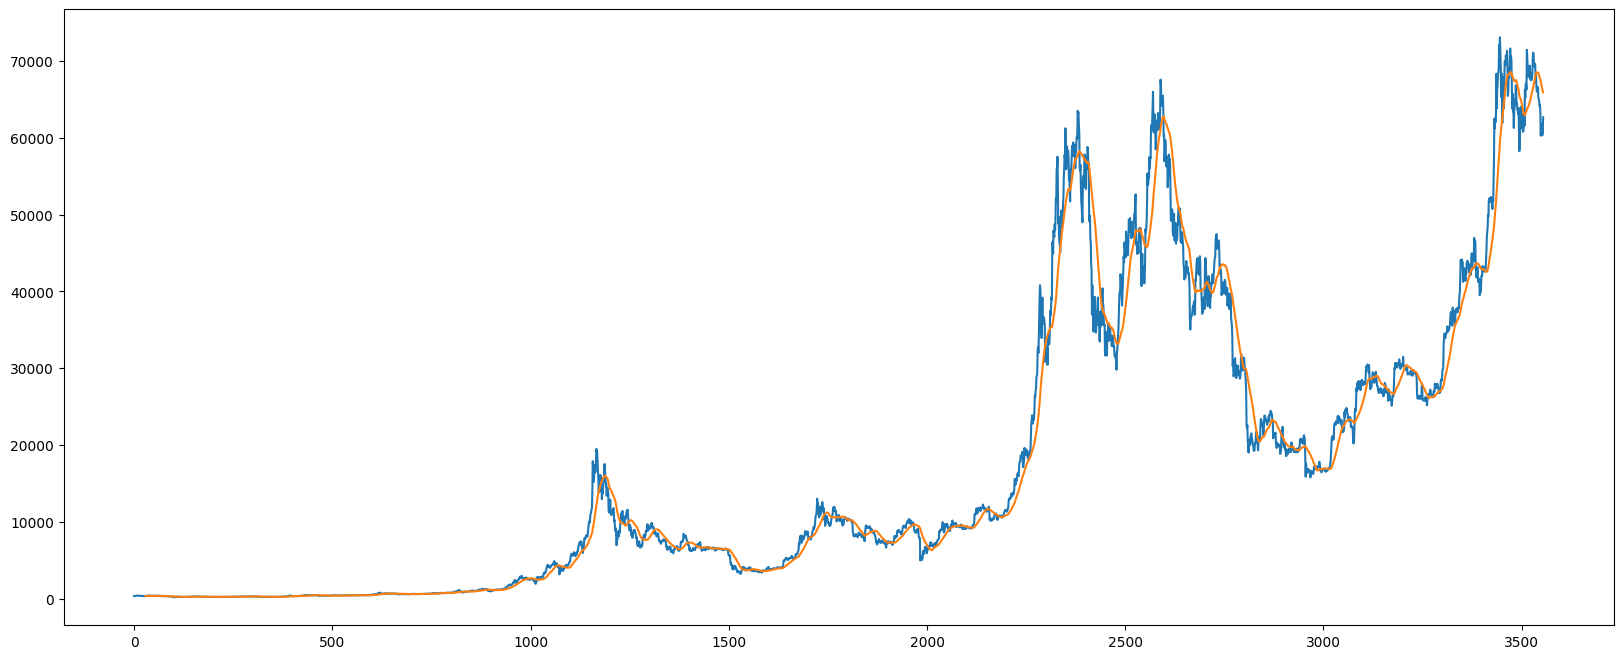

In [17]:
plt.figure(figsize=(20, 8))

df["SMA_30"].dropna(inplace=True)

plt.plot(df["Close"])
plt.plot(df["SMA_30"])


In [19]:
df["CloseTomorrow_1"] = df["Close"].shift(-1)
df["CloseTomorrow_2"] = df["Close"].shift(-2)
df["CloseTomorrow_3"] = df["Close"].shift(-3)

X = df[["Open", "High", "Low", "Close"]]
y = df[["CloseTomorrow_1", "CloseTomorrow_2", "CloseTomorrow_3"]]

df[["Close", "CloseTomorrow_1", "CloseTomorrow_2", "CloseTomorrow_3"]]

,Close,CloseTomorrow_1,CloseTomorrow_2,CloseTomorrow_3
0,336.187012,352.940002,365.026001,361.562012
1,352.940002,365.026001,361.562012,362.299011
2,365.026001,361.562012,362.299011,378.549011
3,361.562012,362.299011,378.549011,390.414001
4,362.299011,378.549011,390.414001,400.869995
...,...,...,...,...
3550,60811.277344,61604.800781,60320.136719,60887.378906
3551,61604.800781,60320.136719,60887.378906,62678.292969
3552,60320.136719,60887.378906,62678.292969,NaN
3553,60887.378906,62678.292969,NaN,NaN


In [24]:
sequence_len = 7
n_samples, n_features = df.shape

X = []

y = []
for i in range(0, n_samples - sequence_len):
    batch = df.iloc[i:i + sequence_len]
    X.append(batch["Close"].tolist())
    y.append(df["Close"].iloc[i + sequence_len])

['2014-10-07', '2014-10-08', '2014-10-09', '2014-10-10', '2014-10-11', '2014-10-12', '2014-10-13'] 2014-10-14
['2014-10-08', '2014-10-09', '2014-10-10', '2014-10-11', '2014-10-12', '2014-10-13', '2014-10-14'] 2014-10-15
['2014-10-09', '2014-10-10', '2014-10-11', '2014-10-12', '2014-10-13', '2014-10-14', '2014-10-15'] 2014-10-16
['2014-10-10', '2014-10-11', '2014-10-12', '2014-10-13', '2014-10-14', '2014-10-15', '2014-10-16'] 2014-10-17
['2014-10-11', '2014-10-12', '2014-10-13', '2014-10-14', '2014-10-15', '2014-10-16', '2014-10-17'] 2014-10-18
['2014-10-12', '2014-10-13', '2014-10-14', '2014-10-15', '2014-10-16', '2014-10-17', '2014-10-18'] 2014-10-19
['2014-10-13', '2014-10-14', '2014-10-15', '2014-10-16', '2014-10-17', '2014-10-18', '2014-10-19'] 2014-10-20
['2014-10-14', '2014-10-15', '2014-10-16', '2014-10-17', '2014-10-18', '2014-10-19', '2014-10-20'] 2014-10-21
['2014-10-15', '2014-10-16', '2014-10-17', '2014-10-18', '2014-10-19', '2014-10-20', '2014-10-21'] 2014-10-22
['2014-10-

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder, OneHotEncoder

X = np.array([[3, 4]])


poly_features = PolynomialFeatures(degree=3)
X_poly = poly_features.fit_transform(X)
X_poly

In [28]:
from math import comb

n, d = 4,3
count = comb(n, d)
print(count)

4


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

X = []
y = []

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf = KNeighborsClassifier()
# clf.fit(X_scaled, y)

ValueError: Expected 2D array, got 1D array instead:
array=[].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [ ]:
new_X = [[7]]

new_X_scaled = scaler.transform(new_X)
clf.predict(new_X_scaled)

In [34]:
from sklearn.pipeline import Pipeline

train_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

train_pipeline

# train_pipeline.fit(X_scaled, y)


# new_X = [[7]]
# train_pipeline.predict(new_X)

Pipeline(steps=[('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
df = pd.read_csv("data.csv")

X = df[["day","amount", "count"]]
y = df["result"]

text_columns = df.select_dtypes(include=["object", "string"])
numbers_columns = df.select_dtypes(include=["number", "int", "float"])


pre_process = ColumnTransformer([
    ("scaler", StandardScaler(), ["amount", "count"]),
    ("encode", TfidfVectorizer(), "day")
])

train_pipeline = Pipeline([
    ("pre_process", pre_process),
    ("clf", KNeighborsClassifier())
])


train_pipeline
train_pipeline.fit(X,y)
train_pipeline.predict(X)

import pickle

with open("pipeline.pkl", "wb") as file:
    pickle.dump(train_pipeline, file)

with open("pipeline.pkl", "rb") as file:
    pipeline = pickle.load(file)





Pipeline(steps=[('pre_process',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['amount', 'count']),
                                                 ('encode', TfidfVectorizer(),
                                                  'day')])),
                ('clf', KNeighborsClassifier())])

In [44]:

print(text_columns)
print(numbers_columns)

   day
0  sun
1  mon
2  tue
3  wed
   amount  count  result
0    1000      2       0
1    2000      1       0
2    1500      2       1
3    1800      3       1
